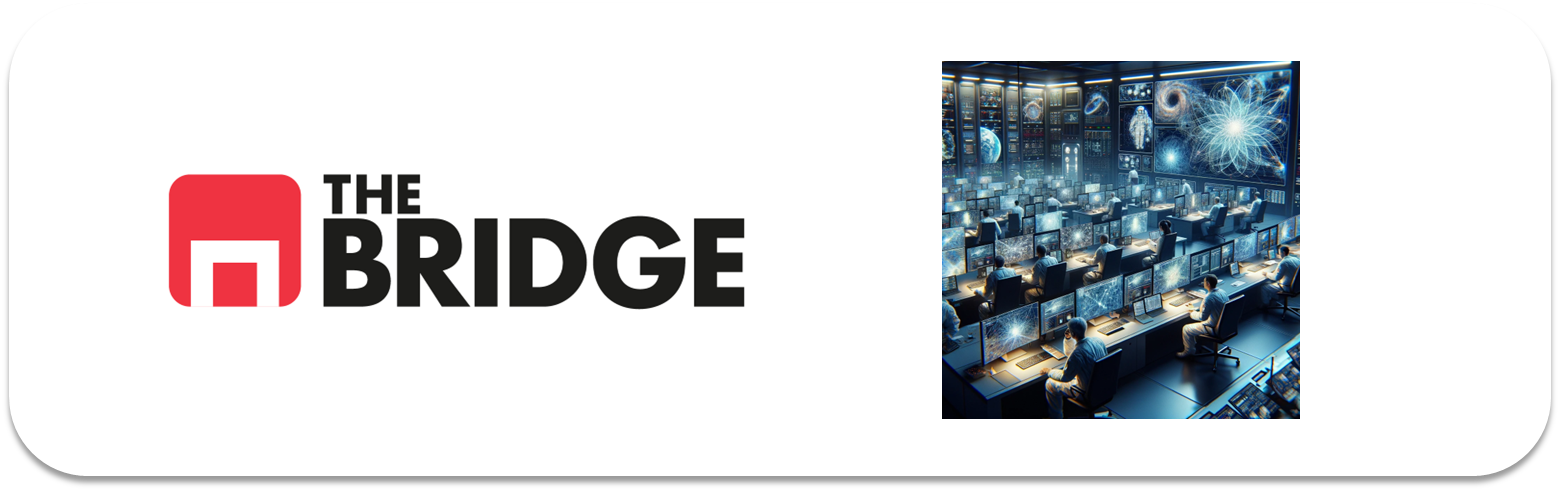

## PRACTICA OBLIGATORIA: **Redes Convolucionales**

* La práctica obligatoria de esta unidad consiste en un ejercicio de construcción de una red convolucional con Keras para la clasificación de imagenes de simpáticos perretes y gatetes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, balanced_accuracy_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.base import clone
from threadpoolctl import threadpool_limits
threadpool_limits(2)
SEED=42
np.random.seed(SEED)
ROOT=next(p for p in Path.cwd().parents if (p/'05_Deep_Learning').exists() and (p/'.git').exists())
CACHE=ROOT/'.cache'/'unidades_siguientes'
CACHE.mkdir(parents=True,exist_ok=True)
os.environ['KERAS_HOME']=str(CACHE/'keras')
os.environ['KAGGLEHUB_CACHE']=str(CACHE/'kaggle')
os.environ['TF_CPP_MIN_LOG_LEVEL']='2'
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
tf.keras.utils.set_random_seed(SEED)
tf.config.threading.set_intra_op_parallelism_threads(2)
tf.config.threading.set_inter_op_parallelism_threads(2)
print('TensorFlow:',tf.__version__,'GPUs:',len(tf.config.list_physical_devices('GPU')))
from PIL import Image
import json
def read_images(folder,size=(32,32),labels_from_filename=False):
 folder=Path(folder);files=sorted(p for p in folder.rglob('*') if p.suffix.lower() in ['.jpg','.jpeg','.png'])
 if not files:raise FileNotFoundError(f'Sin imágenes: {folder}')
 images=[];labels=[]
 for p in files:
  with Image.open(p) as img:images.append(np.asarray(img.convert('RGB').resize(size)))
  labels.append(p.name.split('.')[0] if labels_from_filename else p.parent.name)
 return np.asarray(images,dtype=np.uint8),np.asarray(labels),files
def show_images(images,titles=None,indices=None):
 ids=np.arange(min(10,len(images))) if indices is None else np.asarray(indices)[:10]
 if len(ids)==0:print('Sin imágenes que cumplan el criterio.');return
 fig,axes=plt.subplots((len(ids)+4)//5,5,figsize=(15,3*((len(ids)+4)//5)),squeeze=False)
 for ax in axes.flat:ax.axis('off')
 for ax,i in zip(axes.flat,ids):
  ax.imshow(images[i]);ax.set_title(str(titles[i]) if titles is not None else str(i),fontsize=8)
 plt.tight_layout();plt.show()
def plot_history(history):
 h=pd.DataFrame(history.history)
 fig,axes=plt.subplots(1,2,figsize=(12,4))
 h[['loss','val_loss']].plot(ax=axes[0]);h[['accuracy','val_accuracy']].plot(ax=axes[1]);plt.show()
 print('Mejor época val_loss:',int(h.val_loss.argmin())+1,'de',len(h),'gap accuracy final:',float(h.accuracy.iloc[-1]-h.val_accuracy.iloc[-1]))
def evaluate_model(model,X,y,names):
 probs=model.predict(X,batch_size=128,verbose=0)
 if probs.shape[1]==1:
  probs=np.column_stack([1-probs[:,0],probs[:,0]])
 pred=probs.argmax(axis=1)
 print(classification_report(y,pred,labels=np.arange(len(names)),target_names=names,zero_division=0))
 fig,ax=plt.subplots(figsize=(9,8));ConfusionMatrixDisplay.from_predictions(y,pred,display_labels=names,normalize='true',ax=ax,xticks_rotation=60);plt.show()
 return {'accuracy':accuracy_score(y,pred),'balanced_accuracy':balanced_accuracy_score(y,pred)},probs
def callbacks(patience=4):return [keras.callbacks.EarlyStopping(monitor='val_loss',patience=patience,restore_best_weights=True)]

TensorFlow: 2.21.0 GPUs: 0


### Problema de Negocio y dataset

Una conocida empresa de información inmobiliaria utiliza un CAPTCHA visual de perros y gatos para detectar webscrappings intensivos y ataques de denegación de servicio. Últimamente, ha detectado que su sistema está empezando a flojear, es decir que hay muchos sistemas de detección automática de imágenes que son capaces de detectar que es un perro y un gato y salterse el CAPTCHA antirobots. Por eso nos ha pedido que entrenemos un modelo potente de clasificación que emule a estos sistemas con el objetivo de emplear como fotografías para el CAPTCHA aquellas que no sepa detectar este sistema emulador de chicos malos.  

Pues manos a la obra, tenemos que seleccionar en un conjunto de 1000 imágenes aquellas que peor se le daría clasificar a un potencial sistema anti-CAPTCHA.  

Para ello vamos a emplear un conjunto de train de 4000 imágenes de perretes y gatetes que se encuentran distribuidas en "data" en cuatro directorios "github_train_0",  "github_train_1", "githun_train_2" y "github_train_3". Los datos de las imagenes que tenemos que clasificar y luego seleccionar como las más "difíciles" están en "data" en el directorio "github_test".


### Se pide

1. Crear los datasets X,y de train y test, leyendo las imágenes de los directorios correspondientes (tendrás que leer todas las imágenes de los cuatro directorios para train) y a la vez que se leen adpatar su resolución para que todas tengan un tamaño de 32x32. En este caso puedes adaptar las funciones de los ejercicios de la unidad. NOTA: Ten en cuenta que la clase a la que pertenece en la foto está en el nombre del archivo.

2. Crea un modelo DL basado en redes convolucionales con al menos dos juegos Convolucional-Pooling. Sigue todo el proceso de ML (visualización del dataset, MiniEDA, Construcción del modelo)

3. Entrenar el modelo con un callback de Earlystopping con paciencia la que tengas :-). Muestra su historial de entrenamiento.

4. Evalua el modelo, haz un reporte de clasificacion y muestra la matriz de confianza.

5. Es el momento de seleccionar las imagenes: Selecciona el 10% de imágenes mal clasificadas de una y otra clase que tengan el mayor nivel de confianza de que pertenencían a la clase errónea. Es decir las imágenes de perros clasificadas como gatos y con la probabilidad de ser perror más alta.


### Extra (para hacer en clase)

Repite los pasos 3 a 5 utilizando el generador de imágenes sintéticas o Image Augmentation de Keras. 



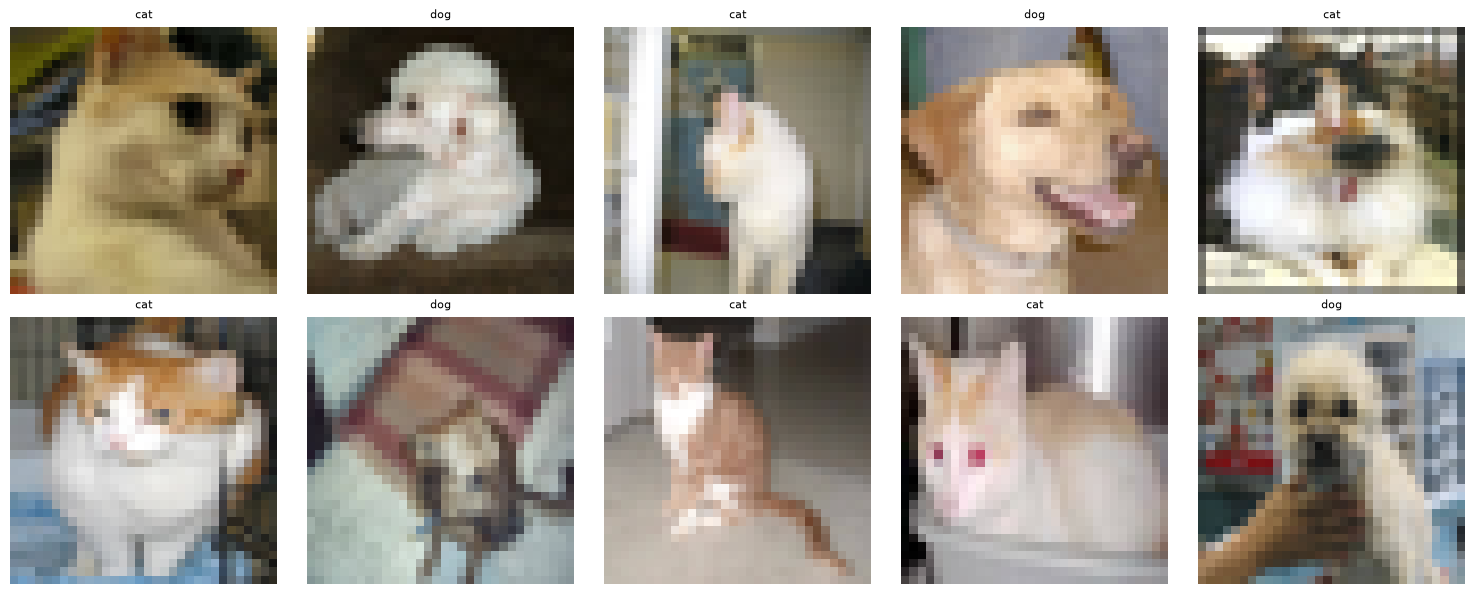

cat    2000
dog    2000
Name: count, dtype: int64

(4000, 32, 32, 3) (1000, 32, 32, 3)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 543,937 (2.07 MB)

...

25/25 - 1s - 53ms/step - accuracy: 0.8525 - loss: 0.3483 - val_accuracy: 0.7487 - val_loss: 0.5215


Epoch 16/35


25/25 - 1s - 53ms/step - accuracy: 0.8631 - loss: 0.3275 - val_accuracy: 0.7487 - val_loss: 0.5313


Epoch 17/35


25/25 - 1s - 56ms/step - accuracy: 0.8694 - loss: 0.3119 - val_accuracy: 0.7513 - val_loss: 0.5315


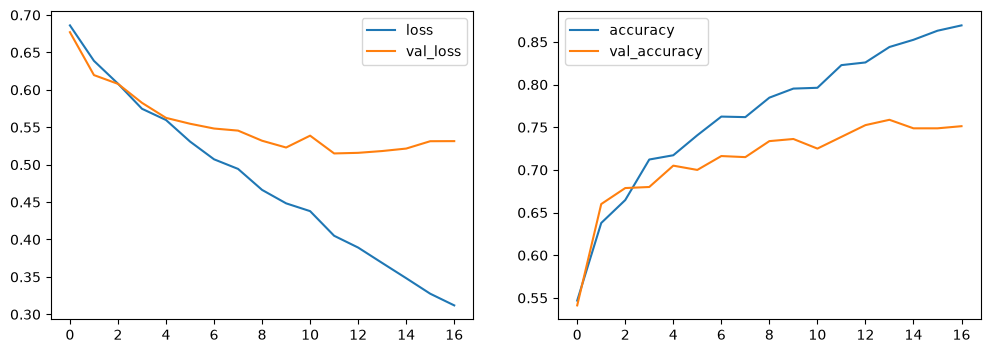

Mejor época val_loss: 12 de 17 gap accuracy final: 0.11812496185302734


              precision    recall  f1-score   support

         cat       0.75      0.77      0.76       500
         dog       0.76      0.74      0.75       500

    accuracy                           0.76      1000
   macro avg       0.76      0.76      0.76      1000
weighted avg       0.76      0.76      0.76      1000



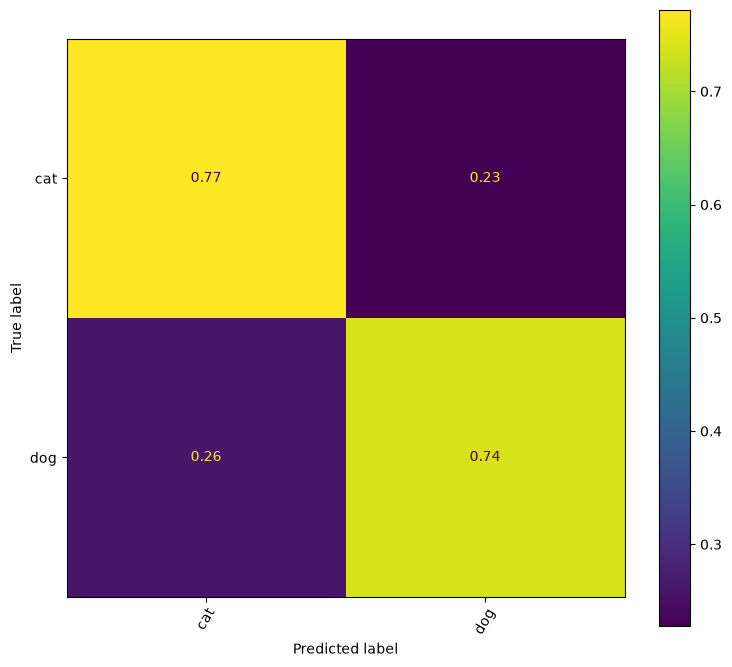

,archivo,real,prediccion,confianza
0,data\github_test\cat.11825.jpg,cat,dog,0.980559
1,data\github_test\cat.11793.jpg,cat,dog,0.966979
2,data\github_test\cat.11462.jpg,cat,dog,0.953827
3,data\github_test\cat.11168.jpg,cat,dog,0.939309
4,data\github_test\cat.11636.jpg,cat,dog,0.935729
5,data\github_test\cat.11240.jpg,cat,dog,0.935358
6,data\github_test\cat.11739.jpg,cat,dog,0.913323
7,data\github_test\cat.11867.jpg,cat,dog,0.910303
8,data\github_test\cat.11125.jpg,cat,dog,0.890429
9,data\github_test\cat.12307.jpg,cat,dog,0.888299


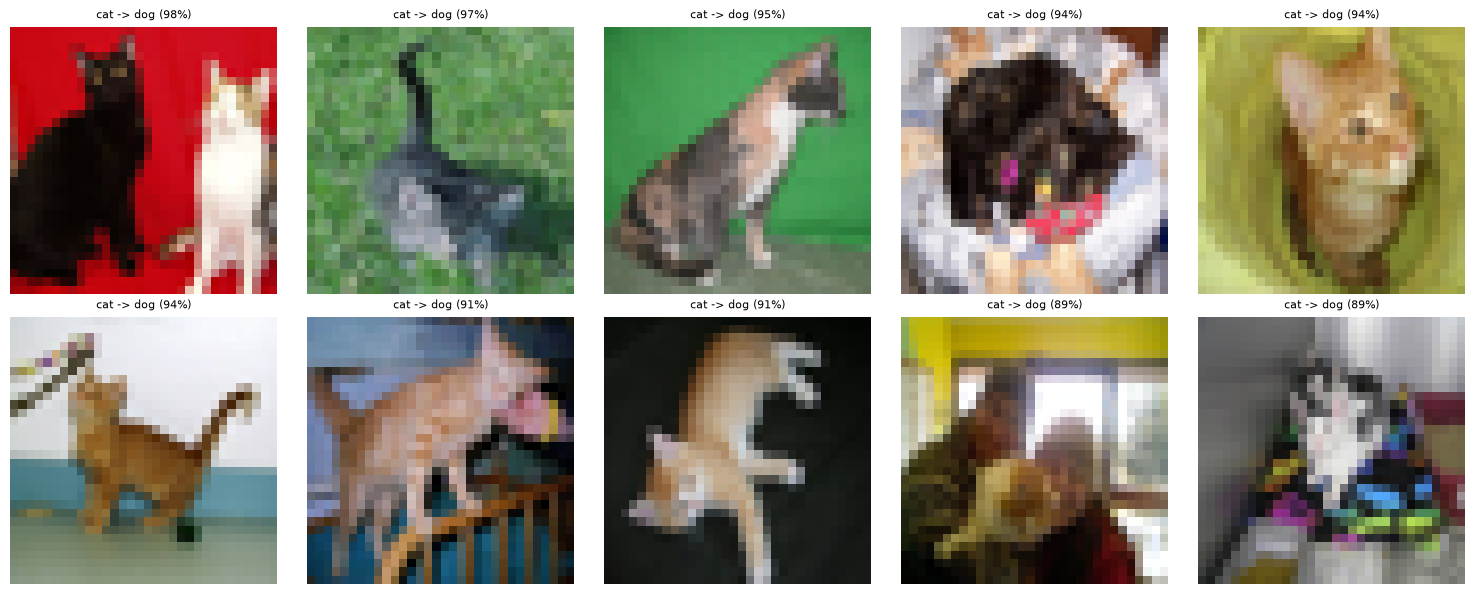

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 543,937 (2.07 MB)

 Trainable params: 543,937 (2.07 MB)

 Non-trainable params: 0 (0.00 B)

...

25/25 - 1s - 56ms/step - accuracy: 0.7494 - loss: 0.5019 - val_accuracy: 0.7312 - val_loss: 0.5741


Epoch 17/35


25/25 - 1s - 56ms/step - accuracy: 0.7588 - loss: 0.4930 - val_accuracy: 0.7262 - val_loss: 0.5572


Epoch 18/35


25/25 - 1s - 55ms/step - accuracy: 0.7600 - loss: 0.4908 - val_accuracy: 0.7375 - val_loss: 0.5579


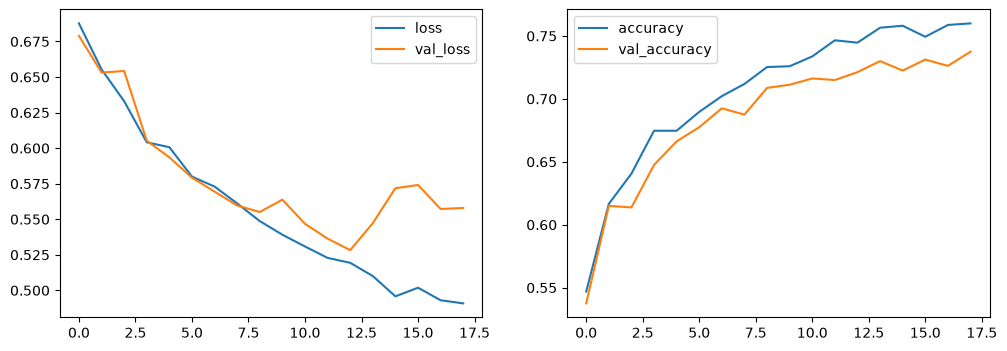

Mejor época val_loss: 13 de 18 gap accuracy final: 0.02249997854232788


              precision    recall  f1-score   support

         cat       0.82      0.61      0.70       500
         dog       0.69      0.87      0.77       500

    accuracy                           0.74      1000
   macro avg       0.75      0.74      0.73      1000
weighted avg       0.75      0.74      0.73      1000



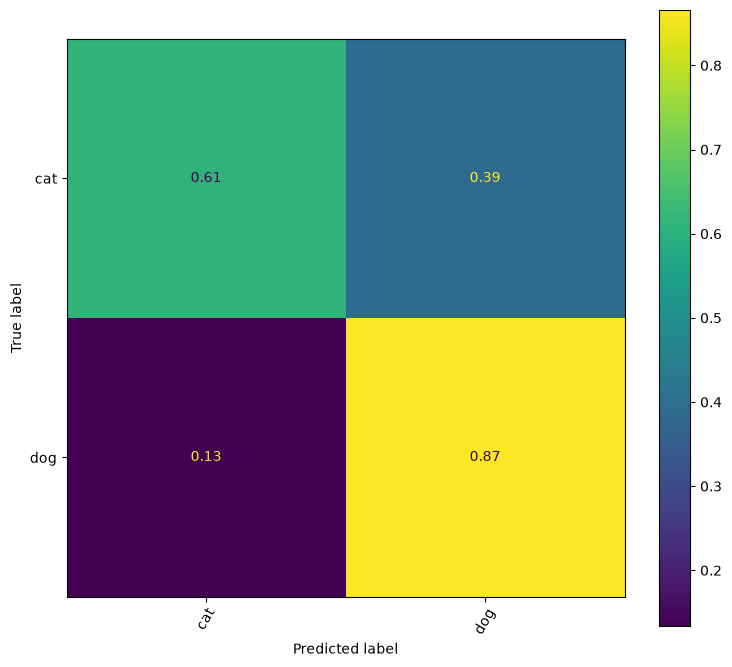

,archivo,real,prediccion,confianza
0,data\github_test\cat.11793.jpg,cat,dog,0.990903
1,data\github_test\cat.11240.jpg,cat,dog,0.966045
2,data\github_test\cat.11636.jpg,cat,dog,0.951625
3,data\github_test\cat.11462.jpg,cat,dog,0.947729
4,data\github_test\cat.11899.jpg,cat,dog,0.934112
5,data\github_test\cat.11825.jpg,cat,dog,0.910582
6,data\github_test\cat.11470.jpg,cat,dog,0.905889
7,data\github_test\cat.11288.jpg,cat,dog,0.896667
8,data\github_test\cat.11093.jpg,cat,dog,0.885150
9,data\github_test\cat.12264.jpg,cat,dog,0.876823


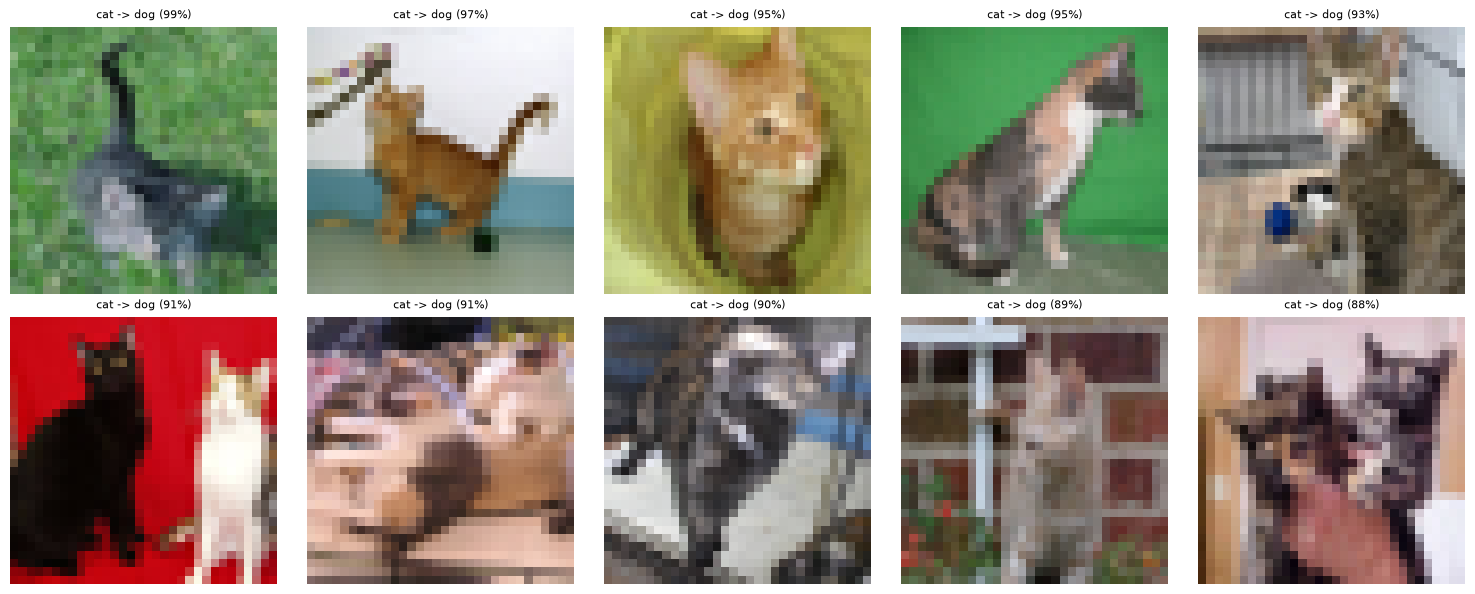

,aumento,accuracy,balanced_accuracy
0,False,0.756,0.756
1,True,0.738,0.738


Se toma el 10% de los errores de cada clase, ordenado por probabilidad de la clase equivocada. El aumento solo actúa al entrenar. Dificultad para esta red no garantiza resistencia frente a otros sistemas.


In [2]:
parts=[read_images(Path('data')/f'github_train_{i}',labels_from_filename=True) for i in range(4)]
X_train=np.concatenate([p[0] for p in parts]);labels=np.concatenate([p[1] for p in parts]);files_train=sum([p[2] for p in parts],[])
X_test,test_labels,files_test=read_images('data/github_test',labels_from_filename=True)
assert len(X_train)==4000 and len(X_test)==1000
names=['cat','dog'];y_train=(labels=='dog').astype(int);y_test=(test_labels=='dog').astype(int)
show_images(X_train,labels,np.random.default_rng(SEED).choice(len(X_train),10,replace=False))
display(pd.Series(labels).value_counts());print(X_train.shape,X_test.shape)
train_idx,valid_idx=train_test_split(np.arange(len(X_train)),test_size=.2,stratify=y_train,random_state=SEED)
def build(augment=False):
 ops=[layers.Input((32,32,3))]
 if augment:ops.extend([layers.RandomFlip('horizontal',seed=SEED),layers.RandomRotation(.08,seed=SEED),layers.RandomZoom(.15,seed=SEED)])
 ops.extend([layers.Rescaling(1/255),layers.Conv2D(32,3,padding='same',activation='relu'),layers.MaxPooling2D(),
  layers.Conv2D(64,3,padding='same',activation='relu'),layers.MaxPooling2D(),layers.Flatten(),
  layers.Dense(128,activation='relu'),layers.Dropout(.4),layers.Dense(1,activation='sigmoid')])
 m=keras.Sequential(ops);m.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy']);return m
results=[]
for augment in [False,True]:
 keras.utils.set_random_seed(SEED);model=build(augment);model.summary()
 history=model.fit(X_train[train_idx],y_train[train_idx],validation_data=(X_train[valid_idx],y_train[valid_idx]),epochs=35,batch_size=128,callbacks=callbacks(5),verbose=2)
 plot_history(history);score,probs=evaluate_model(model,X_test,y_test,names);results.append(dict(aumento=augment,**score))
 pred=probs.argmax(axis=1)
 selected=[]
 for cls in [0,1]:
  wrong=np.flatnonzero((y_test==cls)&(pred!=y_test))
  wrong=wrong[np.argsort(probs[wrong].max(axis=1))[::-1]]
  selected.extend(wrong[:int(np.ceil(.1*len(wrong)))].tolist())
 selection=pd.DataFrame({'archivo':[str(files_test[i].relative_to(Path.cwd())) if files_test[i].is_absolute() else str(files_test[i]) for i in selected],
  'real':[names[y_test[i]] for i in selected],'prediccion':[names[pred[i]] for i in selected],'confianza':probs[selected].max(axis=1) if selected else []})
 display(selection);show_images(X_test,[f'{names[a]} -> {names[b]} ({c:.0%})' for a,b,c in zip(y_test,pred,probs.max(axis=1))],selected)
display(pd.DataFrame(results))
print('Se toma el 10% de los errores de cada clase, ordenado por probabilidad de la clase equivocada. El aumento solo actúa al entrenar. Dificultad para esta red no garantiza resistencia frente a otros sistemas.')